# Lab 6: Hinges and cyclic quadrilaterals
**Python supplement · Worked solutions · English**

Visualize an improving hinge motion and separate side-length feasibility from area maximality.

These two exercises supplement the mathematical lab; they are not
additional required work inside its original 90-minute schedule.
Allow roughly 60–90 minutes, depending on Python experience.

Run the setup cell first, then work from top to bottom. The task functions
are completed in this version. The demonstration cells generate the figures
and run mathematical checks; discussion guidance follows each exercise.

A plot, finite search or successful iteration supplies numerical
evidence. State separately any theorem used to establish existence,
global optimality or an equality case.


This version contains completed code and discussion guidance. All plots and checks can be reproduced with **Restart Kernel and Run All**.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 11,
                     'axes.grid': True, 'grid.alpha': 0.25,
                     'figure.constrained_layout.use': True})

def closed(v):
    """Repeat the first vertex only for plotting."""
    return np.vstack([v, v[0]])

def area(v):
    """Unsigned shoelace area of an ordered simple polygon."""
    return abs(np.sum(v[:, 0]*np.roll(v[:, 1], -1)
                      - v[:, 1]*np.roll(v[:, 0], -1)))/2

def perimeter(v):
    return np.linalg.norm(np.roll(v, -1, axis=0)-v, axis=1).sum()

def outline(ax, v, **kwargs):
    p = closed(v)
    ax.plot(p[:, 0], p[:, 1], **kwargs)
    ax.set_aspect('equal', adjustable='box')




## Exercise 6.1: Two fixed bars and the hinge angle

Fix $a=3$, $b=4$ and vary the angle $\theta\in[30^\circ,150^\circ]$
at $C$. Put $C=(0,0)$, $A=(a,0)$, $B=(b\cos\theta,b\sin\theta)$.
The two attached caps have a fixed total area $c=2.5$. The reflected
full-region area in the lab's bookkeeping is
$Q(\theta)=2[c+\frac12ab\sin\theta]$.

**Code tasks (25–35 minutes).**
1. Complete `hinge_family(theta, a, b, cap_area)` to construct the triangles
   and compute the full area. Input angles are in radians.
2. Plot $Q$, mark its best sampled angle, and draw triangles at 45, 90 and
   120 degrees on a common scale.
3. Compare the gain from 60 to 90 degrees with the exact value, then
   use a finite difference to check the derivative sign on either side of 90.

**Return contract:** `(triangles, full_areas)`, of shapes `(m,3,2)` and `(m,)`.
The pictures show the triangle component. They do not assert that arbitrary
attached caps can complete the entire motion without intersection.


In [2]:
def hinge_family(theta, a=3., b=4., cap_area=2.5):
    theta = np.asarray(theta)
    triangles = np.zeros((len(theta),3,2))
    triangles[:,1,0] = a
    triangles[:,2,:] = b*np.column_stack([np.cos(theta),np.sin(theta)])
    full = 2*(cap_area+.5*a*b*np.sin(theta))
    return triangles, full


**Run, visualize and check.** Adapt these plots as requested, and report what changes when you refine the discretization or vary parameters.

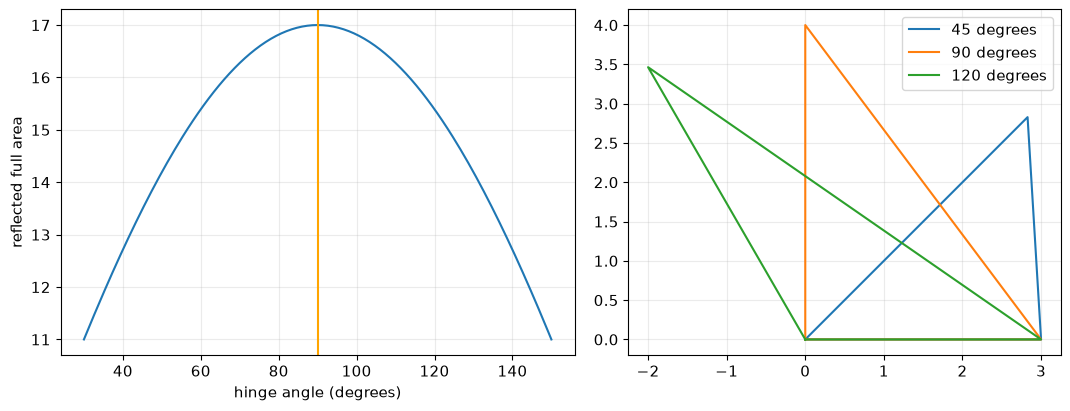

Full-area gain from 60 to 90 degrees: 1.607695154586736


In [3]:
theta = np.linspace(np.pi/6,5*np.pi/6,181)
result = hinge_family(theta)
if result is None:
    print('Complete hinge_family, then rerun this cell.')
else:
    triangles, values = result
    np.testing.assert_allclose(np.linalg.norm(triangles[:,1]-triangles[:,0],axis=1),3.)
    np.testing.assert_allclose(np.linalg.norm(triangles[:,2]-triangles[:,0],axis=1),4.)
    np.testing.assert_allclose(theta[values.argmax()],np.pi/2)
    sample, _ = hinge_family(np.radians([45,90,120]))
    fig, ax = plt.subplots(1,2,figsize=(11,4))
    ax[0].plot(np.degrees(theta),values); ax[0].axvline(90,color='orange')
    ax[0].set(xlabel='hinge angle (degrees)',ylabel='reflected full area')
    for tri,label in zip(sample,[45,90,120]): outline(ax[1],tri,label=f'{label} degrees')
    ax[1].legend(); plt.show()
    _, pair = hinge_family(np.radians([60,90]))
    np.testing.assert_allclose(pair[1]-pair[0],12*(1-np.sqrt(3)/2))
    derivative = np.gradient(values,theta)
    assert derivative[theta < np.radians(85)].min() > 0
    assert derivative[theta > np.radians(95)].max() < 0
    print('Full-area gain from 60 to 90 degrees:',pair[1]-pair[0])


**Explain your observations.** What additional geometric admissibility check is needed when caps are actually moved? Why does the course argument only require a small improving motion?

**Solution guidance:** The fixed-length triangle area is maximized at a right angle; reflected gains are doubled. For actual caps, one must check that the moved boundary remains simple and on the required side of its base. A small improving motion suffices for the contradiction argument.

## Exercise 6.2: Four fixed sides: scan the diagonal

Let $AB=a=2$, $BC=b=3$, $CD=c=2.5$, $DA=d=2$ and use diagonal
$AC=t$. The helper builds $A=(0,0)$, $C=(t,0)$, with $B$ above and
$D$ below the diagonal using the cosine law. Both component triangles
exist when $\max(|a-b|,|c-d|)<t<\min(a+b,c+d)$.

**Code tasks (35–45 minutes).**
1. Complete `quadrilateral_scan(sides, count)`: sample this open interval,
   retain only strictly convex quadrilaterals, and compute area and the
   sum $\alpha+\gamma$ of the angles at $B,D$.
2. Plot area against diagonal length and against angle sum. Draw the best
   sampled quadrilateral and compare with the cyclic configuration.
3. Verify Bretschneider's identity
   $Q^2=\prod(s-a_i)-abcd\cos^2[(\alpha+\gamma)/2]$ and show the
   error to Brahmagupta's bound decreases under grid refinement.

**Return contract:** `(valid_diagonals, areas, angle_sums)`.
The exact cyclic diagonal satisfies
$t_*^2=[cd(a^2+b^2)+ab(c^2+d^2)]/(ab+cd)$.
The convexity filter matters: two valid triangles do not automatically
give a convex quadrilateral in this assembly.


**Provided helper code.** Run this cell before implementing the task.

In [4]:
def quadrilateral(t,sides):
    a,b,c,d=sides
    xb=(a*a+t*t-b*b)/(2*t)
    xd=(d*d+t*t-c*c)/(2*t)
    yb=np.sqrt(max(0.,a*a-xb*xb))
    yd=np.sqrt(max(0.,d*d-xd*xd))
    return np.array([[0.,0.],[xb,yb],[t,0.],[xd,-yd]])


In [5]:
def quadrilateral_scan(sides, count=501):
    a,b,c,d = sides
    lower,upper = max(abs(a-b),abs(c-d)),min(a+b,c+d)
    rows=[]
    for t in np.linspace(lower,upper,count+2)[1:-1]:
        v=quadrilateral(t,sides)
        edges=np.roll(v,-1,axis=0)-v
        nxt=np.roll(edges,-1,axis=0)
        turns=edges[:,0]*nxt[:,1]-edges[:,1]*nxt[:,0]
        if not np.all(turns < -1e-10):
            continue
        alpha=np.arccos(np.clip((a*a+b*b-t*t)/(2*a*b),-1,1))
        gamma=np.arccos(np.clip((c*c+d*d-t*t)/(2*c*d),-1,1))
        rows.append([t,area(v),alpha+gamma])
    return tuple(np.array(rows).T)


**Run, visualize and check.** Adapt these plots as requested, and report what changes when you refine the discretization or vary parameters.

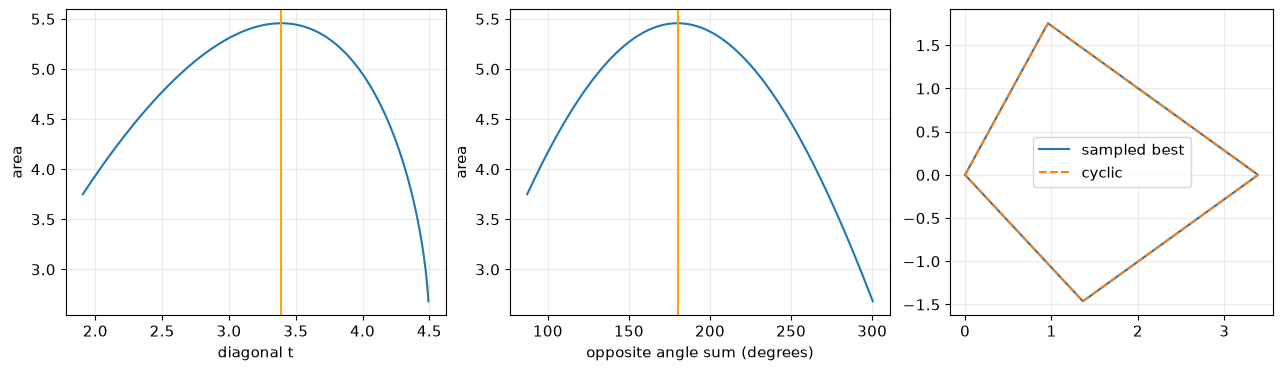

51 samples: area gap=0.0011101976
501 samples: area gap=7.8268136e-08


5001 samples: area gap=5.2889851e-08


In [6]:
sides=np.array([2.,3.,2.5,2.])
result=quadrilateral_scan(sides)
if result is None:
    print('Complete quadrilateral_scan, then rerun this cell.')
else:
    t,values,angle_sum=result
    a,b,c,d=sides; semiperimeter=sides.sum()/2
    bound=np.sqrt(np.prod(semiperimeter-sides))
    exact_t=np.sqrt((c*d*(a*a+b*b)+a*b*(c*c+d*d))/(a*b+c*d))
    np.testing.assert_allclose(values**2,bound**2-np.prod(sides)*np.cos(angle_sum/2)**2,atol=1e-11)
    np.testing.assert_allclose(area(quadrilateral(exact_t,sides)),bound,atol=1e-12)
    best=t[values.argmax()]
    fig,ax=plt.subplots(1,3,figsize=(13,3.6))
    ax[0].plot(t,values); ax[0].axvline(exact_t,color='orange')
    ax[0].set(xlabel='diagonal t',ylabel='area')
    ax[1].plot(np.degrees(angle_sum),values); ax[1].axvline(180,color='orange')
    ax[1].set(xlabel='opposite angle sum (degrees)',ylabel='area')
    outline(ax[2],quadrilateral(best,sides),label='sampled best')
    outline(ax[2],quadrilateral(exact_t,sides),ls='--',label='cyclic'); ax[2].legend()
    plt.show()
    for count in (51,501,5001):
        _,areas,_=quadrilateral_scan(sides,count)
        gap=bound-areas.max()
        assert gap >= -1e-11
        print(f'{count} samples: area gap={gap:.8g}')
    assert gap < 1e-5


**Explain your observations.** Explain why omitting the angle correction would give a wrong formula away from cyclic quadrilaterals. Does this parameter scan settle the existence question for arbitrary shapes?

**Solution guidance:** The correction term vanishes precisely when opposite angles sum to π, giving a cyclic quadrilateral. The scan is a finite-dimensional comparison and does not establish compactness or attainment for a general class of shapes.

**Before submitting:** restart the kernel, run all cells in order, check axis labels and units, and explain any discrepancy between numerical and exact quantities.